Loading datasets...

Pre-calculating all required time series...
  Calculating global mean for thetao between 0m and 700m...
  Calculating global mean for thetao between 0m and 700m...
  Calculating global mean for thetao between 700m and 2000m...
  Calculating global mean for thetao between 700m and 2000m...
  Calculating global mean for thetao between 2000m and 6000m...
  Calculating global mean for thetao between 2000m and 6000m...

Generating final plot...


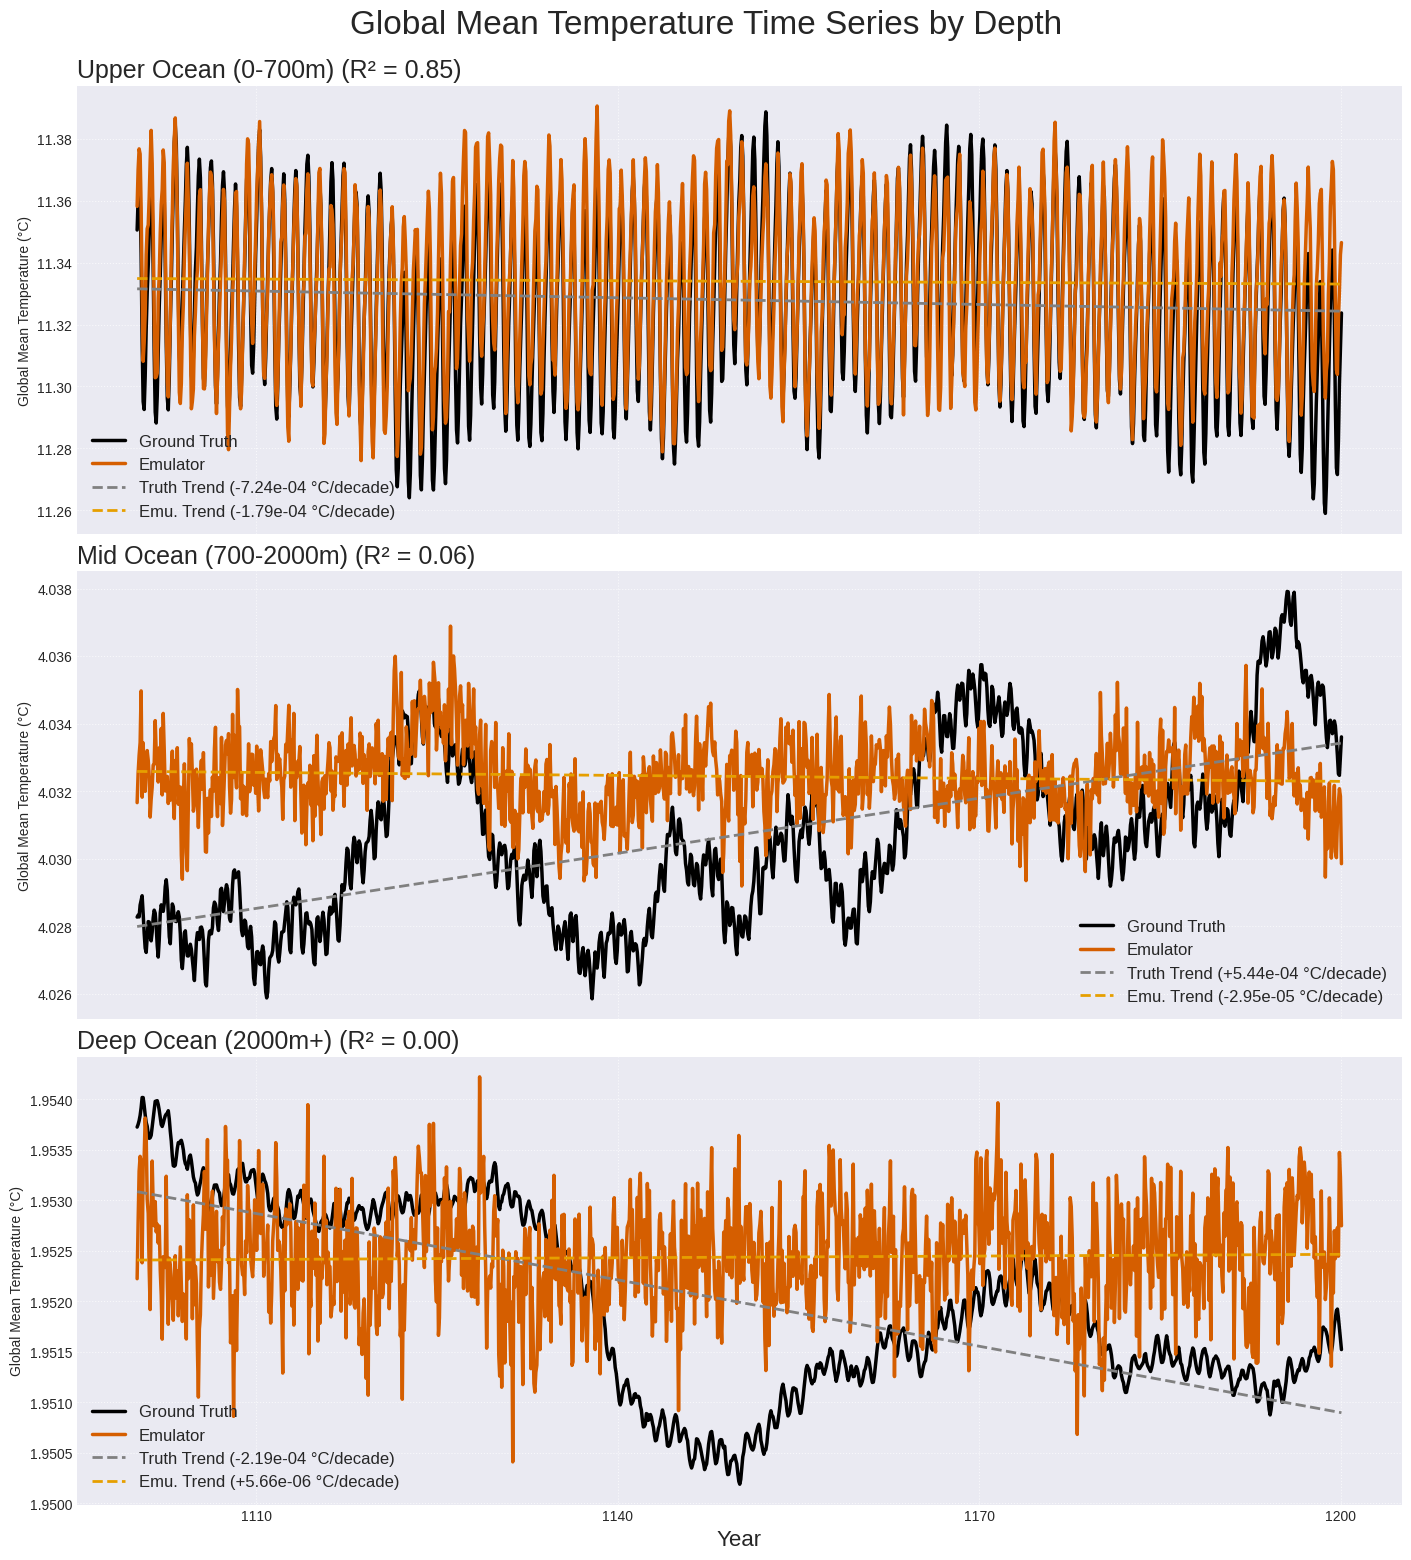

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
# Using placeholder paths from previous scripts. User should verify these.
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Log_hfds.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_Large.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO_TAUUO.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_to_Holocene_Finetuned_Long.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene_piControl_Long_New.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene_from_piControl_Long_New.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_Multistep_More_Levels.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Anomalies.zarr/'
BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Reconstruct_Rollout_w_Vel.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Rollout_Direct.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/RK3_Step_native_diffusion.zarr/'

# The user should ensure these paths point to the correct files.
PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_w_tas.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_1pct.zarr'

PATH_EMU_DATA = f'{BASE_PATH_EMU}' 

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Options: 'thetao', 'so'
EMULATOR_NAME = 'Emulator'   # A descriptive name for the legend

# --- FLEXIBLE: Define which depth slices to analyze and plot ---
# The script will generate one subplot for each dictionary in this list.
DEPTH_SLICES = [
    {'min': 0, 'max': 700, 'title': 'Upper Ocean (0-700m)'},
    {'min': 700, 'max': 2000, 'title': 'Mid Ocean (700-2000m)'},
    {'min': 2000, 'max': 6000, 'title': 'Deep Ocean (2000m+)'},
]

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS
# ==============================================================================

def calculate_global_mean_timeseries(dataset, var_name, areacello, dz, min_depth, max_depth):
    """
    Calculates the area-weighted, depth-averaged global mean time series for a given variable.
    This version assumes no ensemble ('init_time') dimension.
    """
    print(f"  Calculating global mean for {var_name} between {min_depth}m and {max_depth}m...")
    
    # Select the depth range
    field_slice = dataset[var_name].sel(lev=slice(min_depth, max_depth))
    dz_slice = dz.sel(lev=slice(min_depth, max_depth))
    
    # Create a 3D wet mask to handle missing values correctly in the denominator
    wet_mask = xr.where(np.isnan(field_slice.isel(time=0)), 0.0, 1.0)
    
    # Calculate the weighted mean
    numerator = (field_slice * areacello * dz_slice).sum(['x', 'y', 'lev'], skipna=True)
    denominator = (wet_mask * areacello * dz_slice).sum(['x', 'y', 'lev'], skipna=True)
    
    global_mean = numerator / denominator
        
    return global_mean.compute()

def get_trend(timeseries):
    """
    Calculates the linear trend of a time series in units per decade.
    Assumes the time coordinate is in datetime format.
    """
    # Convert time to a numerical value (years from the start) for linear regression
    # Using .time.values ensures compatibility with different calendar types (e.g., cftime)
    time_as_years = (timeseries.time.dt.year + timeseries.time.dt.month/12 - timeseries.time.dt.year[0])
    
    # Perform linear fit
    coeffs = np.polyfit(time_as_years, timeseries.values, 1)
    
    # Slope is in units per year, so multiply by 10 for units per decade
    slope_per_decade = coeffs[0] * 10
    
    # Create the trend line DataArray for plotting
    trend_line = xr.DataArray(
        np.polyval(coeffs, time_as_years),
        dims=['time'],
        coords={'time': timeseries.time}
    )
    
    return slope_per_decade, trend_line

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_timeseries_trends(variable, depth_slices, truth_data, emu_data, units):
    """
    Generates a multi-panel plot comparing emulator and ground truth time series
    at different depth levels, including trends and R-squared values.
    """
    num_plots = len(depth_slices)
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(
        num_plots, 1, 
        figsize=(14, 5 * num_plots), 
        sharex=True,
        constrained_layout=True
    )
    # If only one plot, axes is not a list, so make it one
    if num_plots == 1:
        axes = [axes]

    # --- Loop through each specified depth slice ---
    for i, Slices in enumerate(depth_slices):
        ax = axes[i]
        min_d, max_d = Slices['min'], Slices['max']
        
        # Get pre-calculated time series
        ts_truth = truth_data[f'{min_d}-{max_d}m']
        ts_emu = emu_data[f'{min_d}-{max_d}m']
        
        # Calculate trends and R-squared value
        trend_val_truth, trend_line_truth = get_trend(ts_truth)
        trend_val_emu, trend_line_emu = get_trend(ts_emu)
        
        # Calculate R^2 from pearson R
        r_val, _ = pearsonr(ts_truth.values, ts_emu.values)
        r2_val = r_val**2
        
        # --- Plotting ---
        # Plot the actual time series
        ts_truth.plot(ax=ax, label=f'Ground Truth', color='black', lw=2.5)
        ts_emu.plot(ax=ax, label=f'{EMULATOR_NAME}', color='#D55E00', lw=2.5)
        
        # Plot the trend lines
        trend_line_truth.plot(ax=ax, label=f'Truth Trend ({trend_val_truth:+.2e} {units}/decade)', color='gray', ls='--', lw=2)
        trend_line_emu.plot(ax=ax, label=f'Emu. Trend ({trend_val_emu:+.2e} {units}/decade)', color='#E69F00', ls='--', lw=2)
        
        # --- Formatting ---
        ax.set_title(f"{Slices['title']} (R² = {r2_val:.2f})", fontsize=18, loc='left')
        ax.set_ylabel(f"Global Mean {variable} ({units})")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(fontsize=12)
        ax.set_xlabel('') # Remove xlabel from all but the last plot

    axes[-1].set_xlabel("Year", fontsize=16)
    fig.suptitle(f"Global Mean {variable} Time Series by Depth", fontsize=24, y=1.03)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True).sel(y=slice(-90,64))
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

# The emulator data might use 'year' as the time coordinate. Rename it to 'time'.
if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

# Align time coordinates for fair comparison
# This assumes the emulator provides the time range of interest
time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

# Get grid cell area and thickness from the ground truth dataset
areacello = data_truth['areacello']
dz = data_truth['dz']

# --- 2. Pre-calculate all time series ---
truth_timeseries = {}
emu_timeseries = {}
print("\nPre-calculating all required time series...")
for Slices in DEPTH_SLICES:
    key = f"{Slices['min']}-{Slices['max']}m"
    truth_timeseries[key] = calculate_global_mean_timeseries(
        data_truth, VARIABLE_TO_PLOT, areacello, dz, Slices['min'], Slices['max']
    )
    emu_timeseries[key] = calculate_global_mean_timeseries(
        data_emu, VARIABLE_TO_PLOT, areacello, dz, Slices['min'], Slices['max']
    )
    
# --- 3. Generate the Plot ---
if VARIABLE_TO_PLOT == 'thetao':
    var_label, units = 'Temperature', '°C'
else: # so
    var_label, units = 'Salinity', 'PSU'
    
print("\nGenerating final plot...")
plot_timeseries_trends(
    variable=var_label,
    depth_slices=DEPTH_SLICES,
    truth_data=truth_timeseries,
    emu_data=emu_timeseries,
    units=units
)





Loading datasets...

Pre-calculating all required standard deviation time series...
  Calculating global std. dev. for thetao between 0m and 700m...
  Calculating global std. dev. for thetao between 0m and 700m...
  Calculating global std. dev. for thetao between 700m and 2000m...
  Calculating global std. dev. for thetao between 700m and 2000m...
  Calculating global std. dev. for thetao between 2000m and 6000m...
  Calculating global std. dev. for thetao between 2000m and 6000m...

Generating final plot...


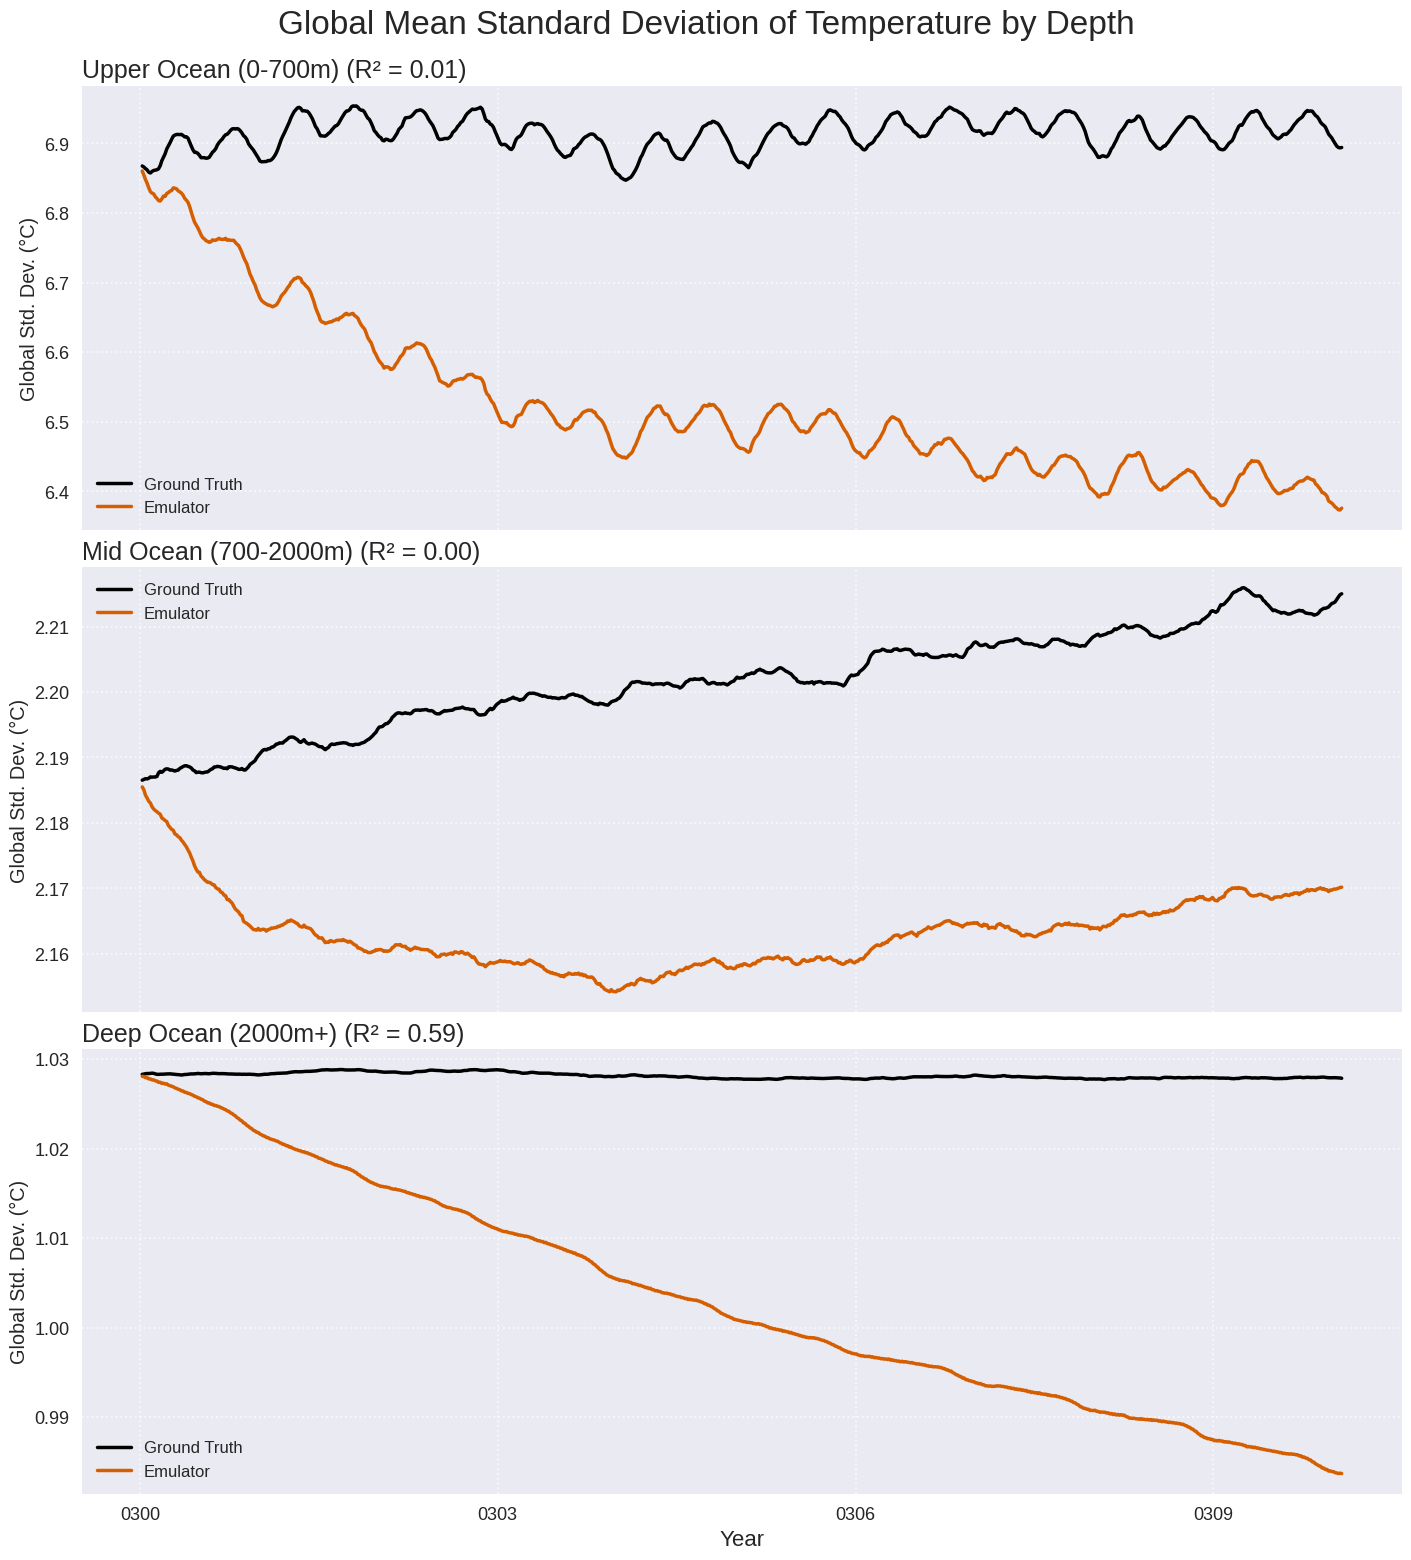

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New_Detrended.zarr'
PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_1pct.zarr'

# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_No_Rad.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_Large.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO_TAUUO.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Rollout_Direct_Scaled.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/RK3_Step_native_diffusion.zarr/'

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Options: 'thetao', 'so'
EMULATOR_NAME = 'Emulator'   # A descriptive name for the legend

# --- FLEXIBLE: Define which depth slices to analyze and plot ---
DEPTH_SLICES = [
    {'min': 0, 'max': 700, 'title': 'Upper Ocean (0-700m)'},
    {'min': 700, 'max': 2000, 'title': 'Mid Ocean (700-2000m)'},
    {'min': 2000, 'max': 6000, 'title': 'Deep Ocean (2000m+)'},
]

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS
# ==============================================================================

def calculate_global_std_timeseries(dataset, var_name, areacello, dz, min_depth, max_depth):
    """
    Calculates the area-weighted, depth-averaged global standard deviation time series.
    """
    print(f"  Calculating global std. dev. for {var_name} between {min_depth}m and {max_depth}m...")
    
    # Select the depth range
    field_slice = dataset[var_name].sel(lev=slice(min_depth, max_depth))
    dz_slice = dz.sel(lev=slice(min_depth, max_depth))
    
    # Create a 3D wet mask and 3D weights
    wet_mask = xr.where(np.isnan(field_slice.isel(time=0)), 0.0, 1.0)
    weights_3d = areacello * dz_slice * wet_mask
    
    # Calculate the sum of weights (denominator)
    sum_of_weights = weights_3d.sum(['x', 'y', 'lev'])
    
    # 1. Calculate the weighted mean time series
    mean_ts = (field_slice * weights_3d).sum(['x', 'y', 'lev']) / sum_of_weights
    
    # 2. Calculate the deviation from the mean
    deviation = field_slice - mean_ts
    
    # 3. Calculate the weighted variance time series
    variance_ts = ((deviation**2) * weights_3d).sum(['x', 'y', 'lev']) / sum_of_weights
    
    # 4. Calculate the standard deviation time series
    std_dev_ts = np.sqrt(variance_ts)
        
    return std_dev_ts.compute()

def get_trend(timeseries):
    """
    Calculates the linear trend of a time series in units per decade.
    """
    # Use the user-provided method for calculating time in years
    time_as_years = (timeseries.time.dt.year + timeseries.time.dt.month/12 - timeseries.time.dt.year[0])
    
    # Perform linear fit
    coeffs = np.polyfit(time_as_years, timeseries.values, 1)
    
    # Slope is in units per year, so multiply by 10 for units per decade
    slope_per_decade = coeffs[0] * 10
    
    # Create the trend line DataArray for plotting
    trend_line = xr.DataArray(
        np.polyval(coeffs, time_as_years),
        dims=['time'],
        coords={'time': timeseries.time}
    )
    
    return slope_per_decade, trend_line

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_timeseries_trends(variable, depth_slices, truth_data, emu_data, units):
    """
    Generates a multi-panel plot comparing emulator and ground truth standard deviation
    time series at different depth levels.
    """
    num_plots = len(depth_slices)
    plt.style.use('seaborn-v0_8-talk')
    fig, axes = plt.subplots(
        num_plots, 1, 
        figsize=(14, 5 * num_plots), 
        sharex=True,
        constrained_layout=True
    )
    if num_plots == 1:
        axes = [axes]

    for i, Slices in enumerate(depth_slices):
        ax = axes[i]
        min_d, max_d = Slices['min'], Slices['max']
        
        ts_truth = truth_data[f'{min_d}-{max_d}m']
        ts_emu = emu_data[f'{min_d}-{max_d}m']
        
        trend_val_truth, trend_line_truth = get_trend(ts_truth)
        trend_val_emu, trend_line_emu = get_trend(ts_emu)
        
        r_val, _ = pearsonr(ts_truth.values, ts_emu.values)
        r2_val = r_val**2
        
        ts_truth.plot(ax=ax, label=f'Ground Truth', color='black', lw=2.5)
        ts_emu.plot(ax=ax, label=f'{EMULATOR_NAME}', color='#D55E00', lw=2.5)
        
        # trend_line_truth.plot(ax=ax, label=f'Truth Trend ({trend_val_truth:+.2e} {units}/decade)', color='gray', ls='--', lw=2)
        # trend_line_emu.plot(ax=ax, label=f'Emu. Trend ({trend_val_emu:+.2e} {units}/decade)', color='#E69F00', ls='--', lw=2)
        
        ax.set_title(f"{Slices['title']} (R² = {r2_val:.2f})", fontsize=18, loc='left')
        ax.set_ylabel(f"Global Std. Dev. ({units})")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(fontsize=12)
        ax.set_xlabel('')

    axes[-1].set_xlabel("Year", fontsize=16)
    fig.suptitle(f"Global Mean Standard Deviation of {variable} by Depth", fontsize=24, y=1.03)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

areacello = data_truth['areacello']
dz = data_truth['dz']

# --- 2. Pre-calculate all time series ---
truth_timeseries = {}
emu_timeseries = {}
print("\nPre-calculating all required standard deviation time series...")
for Slices in DEPTH_SLICES:
    key = f"{Slices['min']}-{Slices['max']}m"
    truth_timeseries[key] = calculate_global_std_timeseries(
        data_truth, VARIABLE_TO_PLOT, areacello, dz, Slices['min'], Slices['max']
    )
    emu_timeseries[key] = calculate_global_std_timeseries(
        data_emu, VARIABLE_TO_PLOT, areacello, dz, Slices['min'], Slices['max']
    )
    
# --- 3. Generate the Plot ---
if VARIABLE_TO_PLOT == 'thetao':
    var_label, units = 'Temperature', '°C'
else: # so
    var_label, units = 'Salinity', 'PSU'
    
print("\nGenerating final plot...")
plot_timeseries_trends(
    variable=var_label,
    depth_slices=DEPTH_SLICES,
    truth_data=truth_timeseries,
    emu_data=emu_timeseries,
    units=units
)





In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_more_levels.zarr'

# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Log_hfds.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_Large.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene_piControl_Long_New.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_Finetuned_Long.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_New_Rad_Epoch_65.zarr'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep.zarr/'
BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/Euler_Step_diffusion_54.zarr/'
# BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/RK3_Step_native_diffusion.zarr/'

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Options: 'thetao', 'so'
EMULATOR_NAME = 'Emulator'   # A descriptive name for the legend

# --- FLEXIBLE: Define which depth slices to analyze and plot ---
# Updated to a 3-panel example to demonstrate the new layout
DEPTH_SLICES = [
    {'min': 0, 'max': 700, 'title': 'Upper Ocean (0-700m)'},
    {'min': 700, 'max': 2000, 'title': 'Mid-Ocean (700-2000m)'},
    {'min': 2000, 'max': 6000, 'title': 'Deep Ocean (2000m+)'},
]

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS
# ==============================================================================

def calculate_vertical_mean_map(dataset, var_name, dz, min_depth, max_depth):
    """
    Calculates the time-mean, depth-averaged horizontal map for a given variable.
    """
    print(f"  Calculating vertical mean map for {var_name} between {min_depth}m and {max_depth}m...")
    
    # Select the depth range
    field_slice = dataset[var_name].sel(lev=slice(min_depth, max_depth))
    dz_slice = dz.sel(lev=slice(min_depth, max_depth))
    
    # Perform the weighted vertical average
    vert_avg_ts = (field_slice * dz_slice).sum('lev', skipna=True) / dz_slice.sum('lev', skipna=True)
    
    # Take the mean over time
    mean_map = vert_avg_ts.mean('time', skipna=True)
        
    return mean_map.compute()

def rmse(truth,pred,area,dims_to_sum = None):
    """Area-weighted RMSE."""
    rmse_val = np.sqrt((area*(truth - pred)**2).sum(dims_to_sum)/area.sum(dims_to_sum))
    return rmse_val

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_bias_maps(bias_maps, rmse_vals, variable, units, cmap=cmocean.cm.balance):
    """
    Generates a multi-panel plot of bias maps for different depth slices
    with a flexible layout.
    """
    num_plots = len(bias_maps)
    
    # --- Flexible Layout Logic ---
    # Use a single row for 3 or fewer plots, otherwise switch to 2 columns
    if num_plots <= 3:
        ncols = num_plots
        nrows = 1
        figsize = (8 * ncols, 7 * nrows)
    else:
        ncols = 2
        nrows = int(np.ceil(num_plots / ncols))
        figsize = (9 * ncols, 6 * nrows)
    
    plt.style.use('seaborn-v0_8-talk')
    fig, axes = plt.subplots(
        nrows, ncols, 
        figsize=figsize, 
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True
    )
    # Ensure axes is always a flattened array for easy iteration
    axes = np.array(axes).flatten()

    
    plot_cmap = cmap.copy()

    # --- Loop through each depth slice ---
    for i, (title, bias_map) in enumerate(bias_maps.items()):
        ax = axes[i]
        rmse_val = rmse_vals[title]

        # Determine a symmetric color scale for EACH panel individually
        max_abs_bias = np.abs(bias_map).max().item()
        max_abs_bias = min(max_abs_bias,2)
        vmin, vmax = -max_abs_bias, max_abs_bias
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        
        # Plot the bias map
        p_mesh = bias_map.plot.pcolormesh(
            ax=ax, transform=ccrs.PlateCarree(), cmap=plot_cmap, norm=norm, add_colorbar=False
        )
        
        # --- Formatting ---
        ax.set_title(f"{title} (RMSE: {rmse_val:.3f} {units})", fontsize=18, loc='left')
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor='black', facecolor='lightgray')
        ax.coastlines()
        ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        
        cbar = fig.colorbar(p_mesh, ax=ax, orientation='vertical', shrink=0.5, pad=0.04)
        cbar.set_label(f"Bias ({units})", fontsize=14)
        cbar.ax.tick_params(labelsize=10)        

    # Hide unused axes if the number of plots is not a perfect rectangle
    for i in range(num_plots, len(axes)):
        axes[i].set_visible(False)



    fig.suptitle(f"Emulator vs. Truth Time-Mean Bias in {variable}", fontsize=24, y=1.05)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

dz = data_truth['dz']
areacello = data_truth['areacello']

# --- 2. Calculate bias maps and RMSE for each depth slice ---
all_bias_maps = {}
all_rmse_vals = {}
print("\nCalculating bias maps and RMSE for each depth slice...")
for Slices in DEPTH_SLICES:
    title = Slices['title']
    
    # Calculate the time-mean map for both truth and emulator
    map_truth = calculate_vertical_mean_map(
        data_truth, VARIABLE_TO_PLOT, dz, Slices['min'], Slices['max']
    )
    map_emu = calculate_vertical_mean_map(
        data_emu, VARIABLE_TO_PLOT, dz, Slices['min'], Slices['max']
    )
    
    # Calculate and store the bias and RMSE
    all_bias_maps[title] = map_emu - map_truth
    all_rmse_vals[title] = rmse(map_truth, map_emu, areacello, dims_to_sum=['x', 'y']).values
    
# --- 3. Generate the Plot ---
if VARIABLE_TO_PLOT == 'thetao':
    var_label, units = 'Temperature', '°C'
else: # so
    var_label, units = 'Salinity', 'PSU'
    
print("\nGenerating final plot...")
plot_bias_maps(
    bias_maps=all_bias_maps,
    rmse_vals=all_rmse_vals,
    variable=var_label,
    units=units
)


Loading datasets...

Calculating bias maps and RMSE for each depth slice...
  Calculating vertical mean map for thetao between 0m and 700m...
  Calculating vertical mean map for thetao between 0m and 700m...
  Calculating vertical mean map for thetao between 700m and 2000m...
  Calculating vertical mean map for thetao between 700m and 2000m...
  Calculating vertical mean map for thetao between 2000m and 6000m...
  Calculating vertical mean map for thetao between 2000m and 6000m...

Generating final plot...


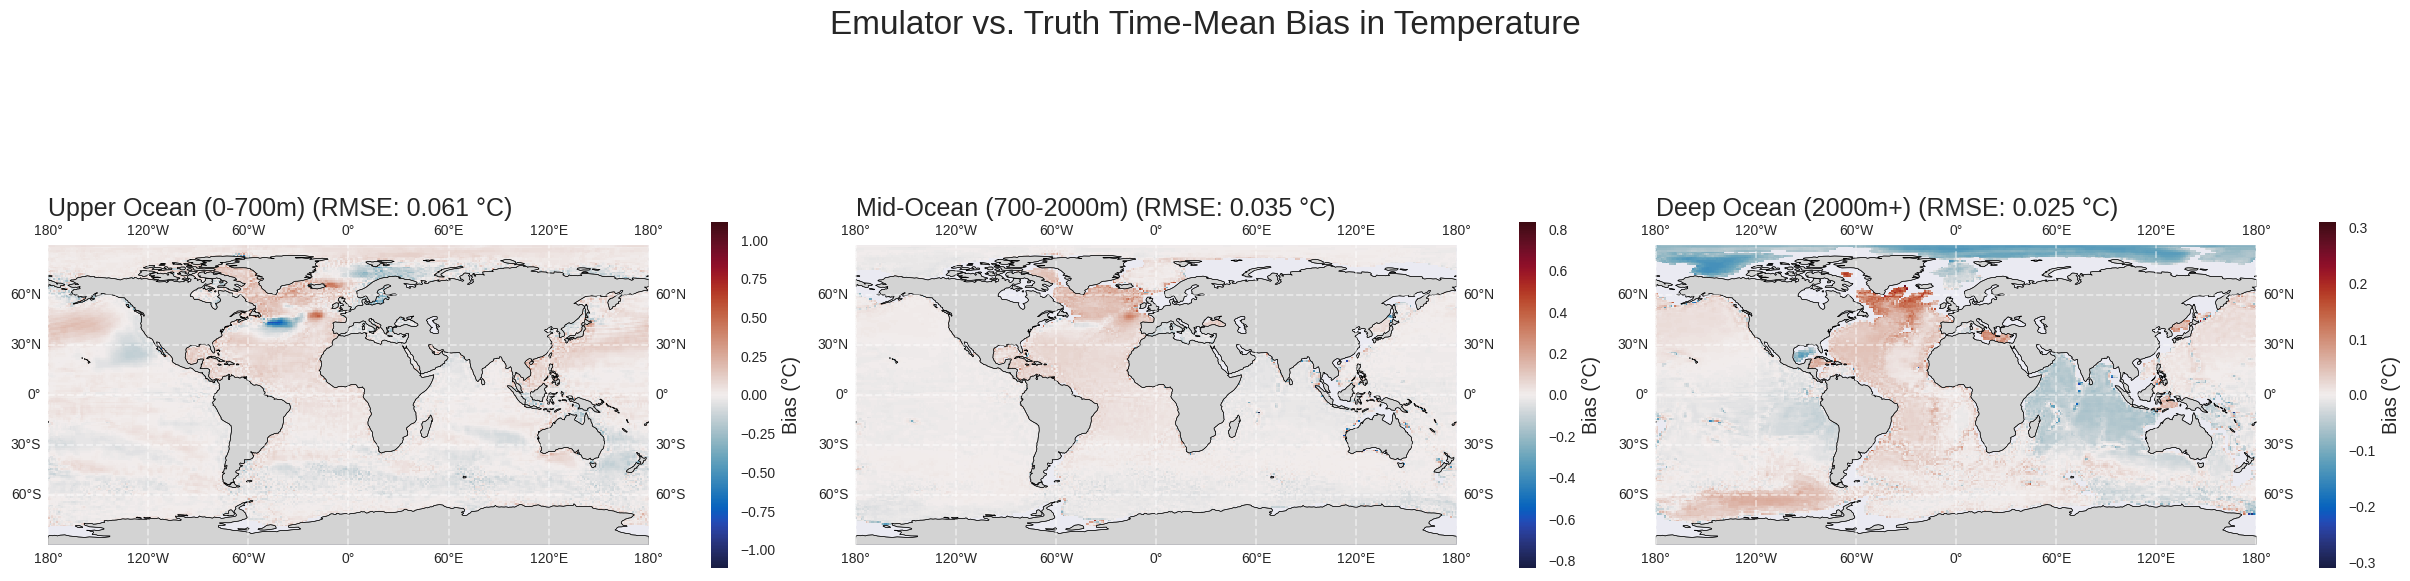

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New_Detrended.zarr'

# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Log_hfds.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_Large.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene_piControl_Long_New.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_Finetuned_Long.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_New_Rad_Epoch_65.zarr'
PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Reconstruct_Rollout_w_Vel.zarr/'


# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Options: 'thetao', 'so'
EMULATOR_NAME = 'Emulator'   # A descriptive name for the legend

# --- FLEXIBLE: Define which depth slices to analyze and plot ---
# Updated to a 3-panel example to demonstrate the new layout
DEPTH_SLICES = [
    {'min': 0, 'max': 700, 'title': 'Upper Ocean (0-700m)'},
    {'min': 700, 'max': 2000, 'title': 'Mid-Ocean (700-2000m)'},
    {'min': 2000, 'max': 6000, 'title': 'Deep Ocean (2000m+)'},
]

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS
# ==============================================================================

def calculate_vertical_mean_map(dataset, var_name, dz, min_depth, max_depth):
    """
    Calculates the time-mean, depth-averaged horizontal map for a given variable.
    """
    print(f"  Calculating vertical mean map for {var_name} between {min_depth}m and {max_depth}m...")
    
    # Select the depth range
    field_slice = dataset[var_name].sel(lev=slice(min_depth, max_depth))
    dz_slice = dz.sel(lev=slice(min_depth, max_depth))
    
    # Perform the weighted vertical average
    vert_avg_ts = (field_slice * dz_slice).sum('lev', skipna=True) / dz_slice.sum('lev', skipna=True)
    
    # Take the mean over time
    mean_map = vert_avg_ts.mean('time', skipna=True)
        
    return mean_map.compute()

def rmse(truth,pred,area,dims_to_sum = None):
    """Area-weighted RMSE."""
    rmse_val = np.sqrt((area*(truth - pred)**2).sum(dims_to_sum)/area.sum(dims_to_sum))
    return rmse_val

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_bias_maps(bias_maps, rmse_vals, variable, units, cmap=cmocean.cm.balance):
    """
    Generates a multi-panel plot of bias maps for different depth slices
    with a flexible layout.
    """
    num_plots = len(bias_maps)
    
    # --- Flexible Layout Logic ---
    # Use a single row for 3 or fewer plots, otherwise switch to 2 columns
    if num_plots <= 3:
        ncols = num_plots
        nrows = 1
        figsize = (8 * ncols, 7 * nrows)
    else:
        ncols = 2
        nrows = int(np.ceil(num_plots / ncols))
        figsize = (9 * ncols, 6 * nrows)
    
    plt.style.use('seaborn-v0_8-talk')
    fig, axes = plt.subplots(
        nrows, ncols, 
        figsize=figsize, 
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True
    )
    # Ensure axes is always a flattened array for easy iteration
    axes = np.array(axes).flatten()

    
    plot_cmap = cmap.copy()

    # --- Loop through each depth slice ---
    for i, (title, bias_map) in enumerate(bias_maps.items()):
        ax = axes[i]
        rmse_val = rmse_vals[title]

        # Determine a symmetric color scale for EACH panel individually
        max_abs_bias = np.abs(bias_map).max().item()
        max_abs_bias = min(max_abs_bias,2)
        vmin, vmax = -max_abs_bias, max_abs_bias
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        
        # Plot the bias map
        p_mesh = bias_map.plot.pcolormesh(
            ax=ax, transform=ccrs.PlateCarree(), cmap=plot_cmap, norm=norm, add_colorbar=False
        )
        
        # --- Formatting ---
        ax.set_title(f"{title} (RMSE: {rmse_val:.3f} {units})", fontsize=18, loc='left')
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor='black', facecolor='lightgray')
        ax.coastlines()
        ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        
        cbar = fig.colorbar(p_mesh, ax=ax, orientation='vertical', shrink=0.5, pad=0.04)
        cbar.set_label(f"Bias ({units})", fontsize=14)
        cbar.ax.tick_params(labelsize=10)        

    # Hide unused axes if the number of plots is not a perfect rectangle
    for i in range(num_plots, len(axes)):
        axes[i].set_visible(False)



    fig.suptitle(f"Emulator vs. Truth Time-Mean Bias in {variable}", fontsize=24, y=1.05)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

dz = data_truth['dz']
areacello = data_truth['areacello']

# --- 2. Calculate bias maps and RMSE for each depth slice ---
all_bias_maps = {}
all_rmse_vals = {}
print("\nCalculating bias maps and RMSE for each depth slice...")
for Slices in DEPTH_SLICES:
    title = Slices['title']
    
    # Calculate the time-mean map for both truth and emulator
    map_truth = calculate_vertical_mean_map(
        data_truth, VARIABLE_TO_PLOT, dz, Slices['min'], Slices['max']
    )
    map_emu = calculate_vertical_mean_map(
        data_emu, VARIABLE_TO_PLOT, dz, Slices['min'], Slices['max']
    )
    
    # Calculate and store the bias and RMSE
    all_bias_maps[title] = map_emu - map_truth
    all_rmse_vals[title] = rmse(map_truth, map_emu, areacello, dims_to_sum=['x', 'y']).values
    
# --- 3. Generate the Plot ---
if VARIABLE_TO_PLOT == 'thetao':
    var_label, units = 'Temperature', '°C'
else: # so
    var_label, units = 'Salinity', 'PSU'
    
print("\nGenerating final plot...")
plot_bias_maps(
    bias_maps=all_bias_maps,
    rmse_vals=all_rmse_vals,
    variable=var_label,
    units=units
)


<>:115: SyntaxWarning: invalid escape sequence '\s'
<>:115: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_161077/4156637063.py:115: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label(f"Bias $\sigma$ ({units})", fontsize=14)


Loading datasets...

Calculating variability bias maps and RMSE for each depth slice...
  Calculating anomaly std. dev. map for thetao between 0m and 700m...
  Calculating anomaly std. dev. map for thetao between 0m and 700m...
  Calculating anomaly std. dev. map for thetao between 700m and 2000m...
  Calculating anomaly std. dev. map for thetao between 700m and 2000m...
  Calculating anomaly std. dev. map for thetao between 2000m and 6000m...
  Calculating anomaly std. dev. map for thetao between 2000m and 6000m...

Generating final plot...


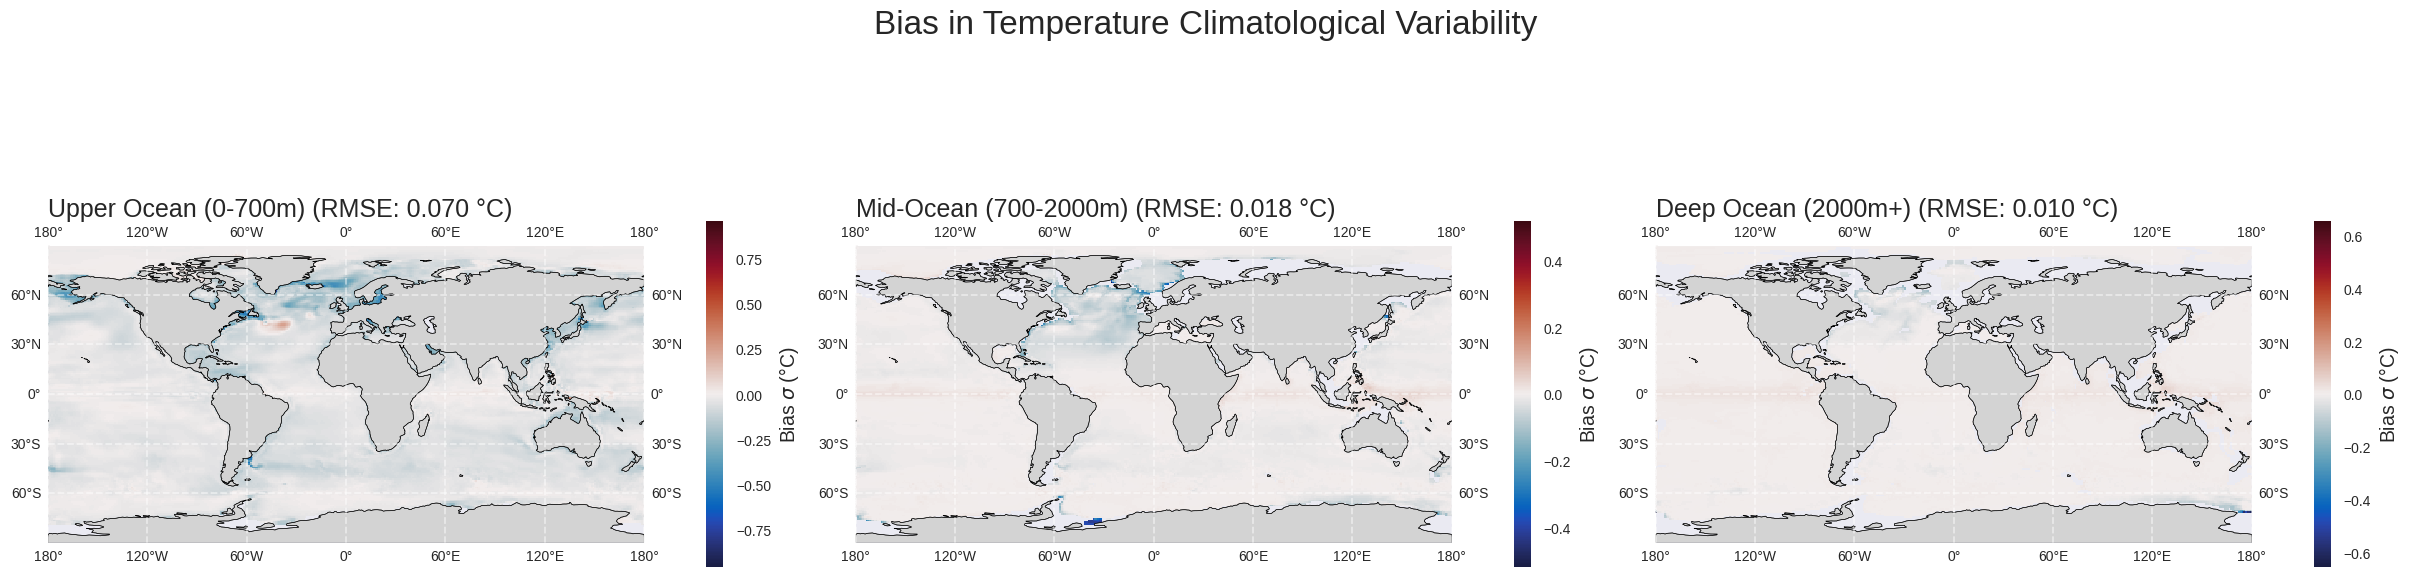

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'

# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene_from_piControl_Long_New.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep.zarr'
PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Reconstruct_Rollout_w_Vel.zarr/'

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Options: 'thetao', 'so'

# --- FLEXIBLE: Define which depth slices to analyze and plot ---
DEPTH_SLICES = [
    {'min': 0, 'max': 700, 'title': 'Upper Ocean (0-700m)'},
    {'min': 700, 'max': 2000, 'title': 'Mid-Ocean (700-2000m)'},
    {'min': 2000, 'max': 6000, 'title': 'Deep Ocean (2000m+)'},
]

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS
# ==============================================================================

def calculate_anomaly_std_map(dataset, var_name, dz, min_depth, max_depth):
    """
    Calculates the standard deviation of climatological anomalies, averaged over a depth layer.
    """
    print(f"  Calculating anomaly std. dev. map for {var_name} between {min_depth}m and {max_depth}m...")
    
    # --- Step 1: Vertically average the data ---
    # This is more computationally efficient than calculating anomalies on the 4D field.
    field_slice = dataset[var_name].sel(lev=slice(min_depth, max_depth))
    dz_slice = dz.sel(lev=slice(min_depth, max_depth))
    vert_avg_ts = (field_slice * dz_slice).sum('lev', skipna=True) / dz_slice.sum('lev', skipna=True)
    
    # --- Step 2: Calculate the climatological anomaly ---
    # Group by month, subtract the monthly mean to remove the seasonal cycle.
    climatology = vert_avg_ts.groupby('time.month').mean('time', skipna=True)
    field_anom = vert_avg_ts.groupby('time.month') - climatology
    
    # --- Step 3: Calculate the standard deviation of the anomaly ---
    # This gives a map of the variability at each grid point.
    std_dev_map = field_anom.std('time', skipna=True)
        
    return std_dev_map.compute()

def rmse(truth, pred, area, dims_to_sum=None):
    """Area-weighted RMSE."""
    rmse_val = np.sqrt((area * (truth - pred)**2).sum(dims_to_sum) / area.sum(dims_to_sum))
    return rmse_val

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_variability_bias_maps(bias_maps, rmse_vals, variable, units, cmap=cmocean.cm.balance):
    """
    Generates a multi-panel plot of the bias in standard deviation for different depth slices.
    """
    num_plots = len(bias_maps)
    
    if num_plots <= 3:
        ncols = num_plots
        nrows = 1
        figsize = (8 * ncols, 7 * nrows)
    else:
        ncols = 2
        nrows = int(np.ceil(num_plots / ncols))
        figsize = (9 * ncols, 6 * nrows)
    
    plt.style.use('seaborn-v0_8-talk')
    fig, axes = plt.subplots(
        nrows, ncols, 
        figsize=figsize, 
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True
    )
    axes = np.array(axes).flatten()

    plot_cmap = cmap.copy()
    # plot_cmap.set_bad(color='grey')

    for i, (title, bias_map) in enumerate(bias_maps.items()):
        ax = axes[i]
        rmse_val = rmse_vals[title]

        # Determine a symmetric color scale for EACH panel individually
        max_abs_bias = np.abs(bias_map).max().item()
        vmin, vmax = -max_abs_bias, max_abs_bias
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        
        p_mesh = bias_map.plot.pcolormesh(
            ax=ax, transform=ccrs.PlateCarree(), cmap=plot_cmap, norm=norm, add_colorbar=False
        )
        
        ax.set_title(f"{title} (RMSE: {rmse_val:.3f} {units})", fontsize=18, loc='left')
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor='black', facecolor='lightgray')
        ax.coastlines()
        ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        
        cbar = fig.colorbar(p_mesh, ax=ax, orientation='vertical', shrink=0.5, pad=0.04)
        cbar.set_label(f"Bias $\sigma$ ({units})", fontsize=14)
        cbar.ax.tick_params(labelsize=10)               

    for i in range(num_plots, len(axes)):
        axes[i].set_visible(False)



    fig.suptitle(f"Bias in {variable} Climatological Variability", fontsize=24, y=1.05)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

dz = data_truth['dz']
areacello = data_truth['areacello']

# --- 2. Calculate variability bias maps and RMSE for each depth slice ---
all_bias_maps = {}
all_rmse_vals = {}
print("\nCalculating variability bias maps and RMSE for each depth slice...")
for Slices in DEPTH_SLICES:
    title = Slices['title']
    
    # Calculate the std. dev. map for both truth and emulator
    map_truth_std = calculate_anomaly_std_map(
        data_truth, VARIABLE_TO_PLOT, dz, Slices['min'], Slices['max']
    )
    map_emu_std = calculate_anomaly_std_map(
        data_emu, VARIABLE_TO_PLOT, dz, Slices['min'], Slices['max']
    )
    
    # Calculate and store the bias in variability and its RMSE
    all_bias_maps[title] = map_emu_std - map_truth_std
    all_rmse_vals[title] = rmse(map_truth_std, map_emu_std, areacello, dims_to_sum=['x', 'y']).values
    
# --- 3. Generate the Plot ---
if VARIABLE_TO_PLOT == 'thetao':
    var_label, units = 'Temperature', '°C'
else: # so
    var_label, units = 'Salinity', 'PSU'
    
print("\nGenerating final plot...")
plot_variability_bias_maps(
    bias_maps=all_bias_maps,
    rmse_vals=all_rmse_vals,
    variable=var_label,
    units=units
)




Loading datasets and grid info...
Calculating grid metrics and loading basin masks...

Calculating bias profiles and RMSE for each basin...
  Processing Atlantic Ocean...
  Processing Pacific Ocean...
  Processing Indian Ocean...
  Processing Southern Ocean...

Generating final plot...


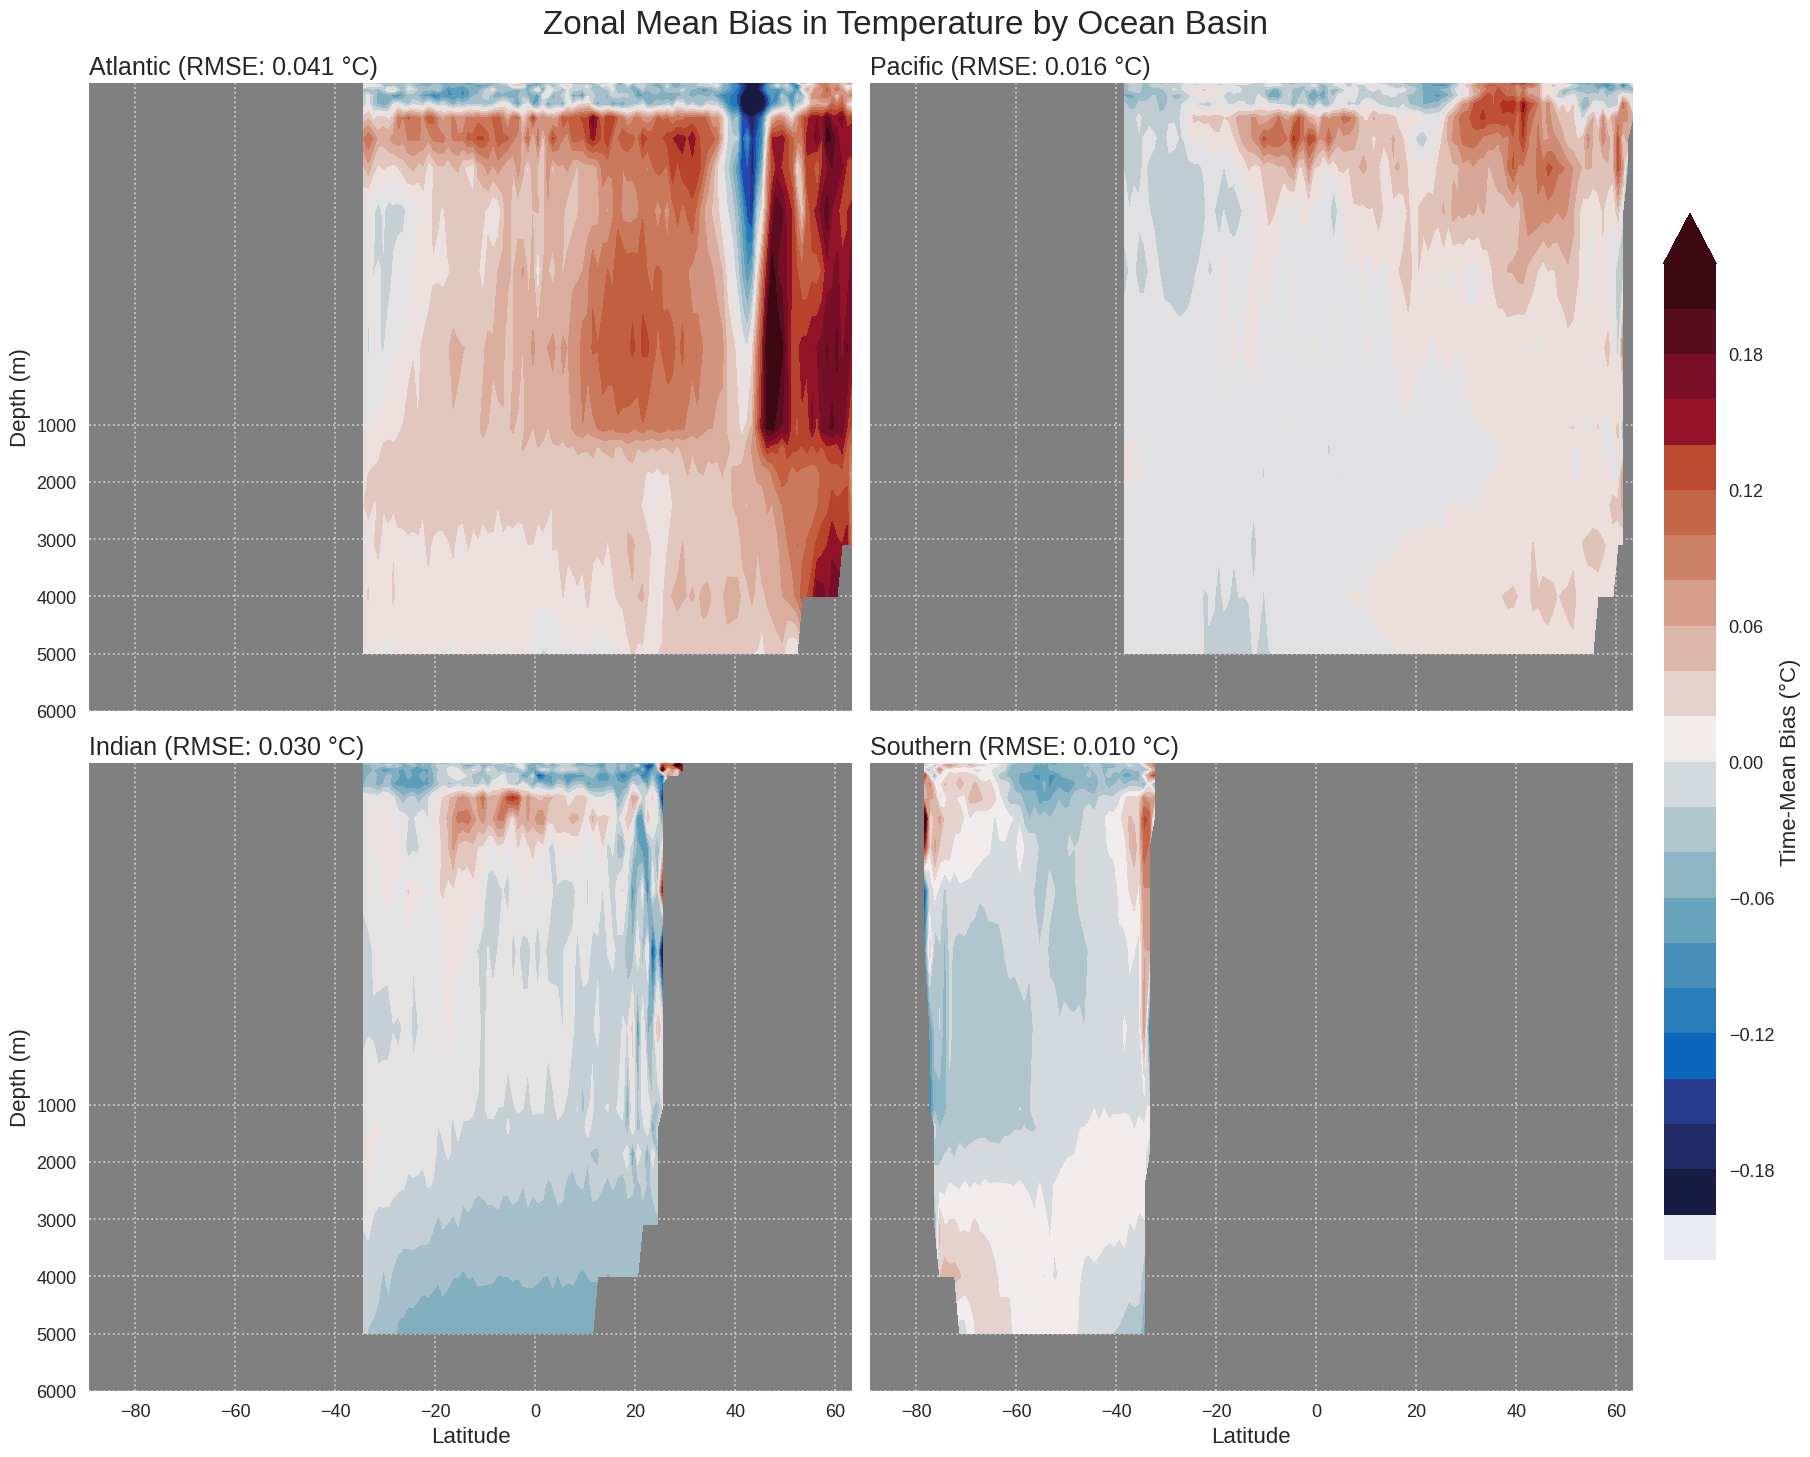

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean
from xarrayutils.plotting import linear_piecewise_scale
%matplotlib inline

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_more_levels.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_1pct.zarr'


# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_New_tas.zarr'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene_from_piControl_Long_New.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep_Chained.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Rollout_Direct_Scaled.zarr/'

PATH_MASKS = f'{BASE_PATH_TRUTH}/Basin_Mask.nc'

PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Reconstruct_Rollout_w_Vel.zarr/'

PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'


# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Options: 'thetao', 'so'

# --- Define which basins to plot ---
# The script will create a subplot for each basin in this list.
BASINS_TO_PLOT = ['Atlantic', 'Pacific', 'Indian', 'Southern']

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS
# ==============================================================================

def get_grid_metrics_and_masks(grid_ref_path, mask_path):
    """
    Calculates grid cell dimensions and loads all specified basin masks.
    """
    print("Calculating grid metrics and loading basin masks...")
    grid_ref = xr.open_zarr(grid_ref_path, consolidated=True)
    R = 6.378e6
        
    lon_b_y_center = ((grid_ref.lon_b[:-1].values + grid_ref.lon_b[1:].values)/2)
    dx = xr.DataArray(lon_b_y_center[:,1:] - lon_b_y_center[:,:-1], dims=('y', 'x'), coords={'y': grid_ref.y, 'x': grid_ref.x})
    lat_b_y_center = ((grid_ref.lat_b[:,:-1].values + grid_ref.lat_b[:,1:].values)/2)
    dy = xr.DataArray(lat_b_y_center[1:] - lat_b_y_center[:-1], dims=('y', 'x'), coords={'y': grid_ref.y, 'x': grid_ref.x})
    dy = (dy/360)*2*np.pi*R
    dx = (dx/360)*2*np.pi*np.cos((grid_ref.lat.values/360)*2*np.pi)*R
    
    # Get dz
    dz = grid_ref['dz']
    
    # Load basin masks
    mask_data = xr.open_dataset(mask_path)
    mask_data = xr.where(mask_data == 4, 5, mask_data)
    # Assuming standard basin codes: 1:SO, 2:Atl, 3:Pac, 5:Ind
    masks = {
        'Atlantic': xr.where(mask_data.basin == 2, 1.0, np.nan),
        'Pacific': xr.where(mask_data.basin == 3, 1.0, np.nan),
        'Indian': xr.where(mask_data.basin == 5, 1.0, np.nan),
        'Southern': xr.where(mask_data.basin == 1, 1.0, np.nan),
    }
    
    return dx, dz, masks

def calculate_zonal_mean_profile(dataset, var_name, dx, basin_mask):
    """
    Calculates the time-mean, zonally-averaged depth-latitude profile for a given basin.
    """
    field = dataset[var_name]
    
    # Take the mean over the time dimension first
    field_time_mean = field.mean('time', skipna=True)
    
    # Create a wet mask from the time-mean field to handle NaNs correctly
    wet_mask = xr.where(np.isnan(field_time_mean), 0.0, 1.0)
    
    # Perform the weighted zonal mean
    zonal_mean = (field_time_mean * dx * basin_mask).sum('x', skipna=True) / (dx * basin_mask * wet_mask).sum('x', skipna=True)
    
    return zonal_mean.compute()

def rmse(truth, pred, area, dims_to_sum=None):
    """Area-weighted RMSE."""
    rmse_val = np.sqrt((area * (truth - pred)**2).sum(dims_to_sum) / area.sum(dims_to_sum))
    return rmse_val

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_zonal_bias_by_basin(bias_profiles, rmse_vals, variable, units, cmap=cmocean.cm.balance):
    """
    Generates a 2x2 plot of zonal mean bias for the four major ocean basins.
    """
    plt.style.use('seaborn-v0_8-talk')
    fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.flatten()

    # Determine a single, symmetric color scale for all bias plots
    max_abs_bias = max(np.abs(bias).max() for bias in bias_profiles.values()).item()*.5
    max_abs_bias = min(.5,max_abs_bias)
    vmin, vmax = -max_abs_bias, max_abs_bias
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    
    plot_cmap = cmap.copy()
    # plot_cmap.set_bad(color='grey')

    for i, basin_name in enumerate(BASINS_TO_PLOT):
        ax = axes[i]
        bias_profile = bias_profiles[basin_name]
        rmse_val = rmse_vals[basin_name]
        
        p_mesh = bias_profile.plot.contourf(
            ax=ax, cmap=plot_cmap, norm=norm, add_colorbar=False, levels=25, yincrease=False
        )
        
        ax.set_title(f"{basin_name} (RMSE: {rmse_val:.3f} {units})", fontsize=18, loc='left')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_facecolor('grey')
        ax.grid(True, linestyle=':', alpha=0.6)
        linear_piecewise_scale(1000, 5, ax=ax)

    # Set outer labels
    axes[0].set_ylabel('Depth (m)', fontsize=16)
    axes[2].set_ylabel('Depth (m)', fontsize=16)
    axes[2].set_xlabel('Latitude', fontsize=16)
    axes[3].set_xlabel('Latitude', fontsize=16)

    # Add a single, shared colorbar
    cbar = fig.colorbar(p_mesh, ax=axes, orientation='vertical', shrink=0.8, pad=0.02)
    cbar.set_label(f"Time-Mean Bias ({units})", fontsize=16)
    
    fig.suptitle(f"Zonal Mean Bias in {variable} by Ocean Basin", fontsize=24, y=1.03)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets and grid info...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)
dx, dz, all_masks = get_grid_metrics_and_masks(PATH_TRUTH_DATA, PATH_MASKS)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

# --- 2. Calculate bias profiles and RMSE for each basin ---
all_bias_profiles = {}
all_rmse_vals = {}
print("\nCalculating bias profiles and RMSE for each basin...")
for basin in BASINS_TO_PLOT:
    print(f"  Processing {basin} Ocean...")
    basin_mask = all_masks[basin]
    
    # Calculate the time-mean zonal profile for both truth and emulator
    profile_truth = calculate_zonal_mean_profile(data_truth, VARIABLE_TO_PLOT, dx, basin_mask)
    profile_emu = calculate_zonal_mean_profile(data_emu, VARIABLE_TO_PLOT, dx, basin_mask)
    
    # Calculate and store the bias
    all_bias_profiles[basin] = profile_emu - profile_truth
    
    # Calculate and store the RMSE
    # Create the 2D area array for weighting
    dx_2d, dz_2d = xr.broadcast(dx.mean('x'), dz)
    area_2d = (dx_2d * dz_2d).mean('x')
    all_rmse_vals[basin] = rmse(profile_truth, profile_emu, area_2d, dims_to_sum=['y', 'lev']).values
    
# --- 3. Generate the Plot ---
if VARIABLE_TO_PLOT == 'thetao':
    var_label, units = 'Temperature', '°C'
else: # so
    var_label, units = 'Salinity', 'PSU'
    
print("\nGenerating final plot...")
plot_zonal_bias_by_basin(
    bias_profiles=all_bias_profiles,
    rmse_vals=all_rmse_vals,
    variable=var_label,
    units=units
)



In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean
from xarrayutils.plotting import linear_piecewise_scale
%matplotlib inline

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'

PATH_MASKS = f'{BASE_PATH_TRUTH}/Basin_Mask.nc'
PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'

PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep.zarr/'

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Options: 'thetao', 'so'

# --- Define which basins to plot ---
BASINS_TO_PLOT = ['Atlantic', 'Pacific', 'Indian', 'Southern']

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS (Reflecting User Updates)
# ==============================================================================

def get_grid_metrics_and_masks(grid_ref_path, mask_path):
    """
    Calculates grid cell dimensions and loads all specified basin masks.
    """
    print("Calculating grid metrics and loading basin masks...")
    grid_ref = xr.open_zarr(grid_ref_path, consolidated=True)
    R = 6.378e6
        
    lon_b_y_center = ((grid_ref.lon_b[:-1].values + grid_ref.lon_b[1:].values)/2)
    dx = xr.DataArray(lon_b_y_center[:,1:] - lon_b_y_center[:,:-1], dims=('y', 'x'), coords={'y': grid_ref.y, 'x': grid_ref.x})
    lat_b_y_center = ((grid_ref.lat_b[:,:-1].values + grid_ref.lat_b[:,1:].values)/2)
    dy = xr.DataArray(lat_b_y_center[1:] - lat_b_y_center[:-1], dims=('y', 'x'), coords={'y': grid_ref.y, 'x': grid_ref.x})
    dy = (dy/360)*2*np.pi*R
    dx = (dx/360)*2*np.pi*np.cos((grid_ref.lat.values/360)*2*np.pi)*R
    
    # Get dz
    dz = grid_ref['dz']
    
    # Load basin masks
    mask_data = xr.open_dataset(mask_path)
    mask_data = xr.where(mask_data == 4, 5, mask_data)
    # Assuming standard basin codes: 1:SO, 2:Atl, 3:Pac, 5:Ind
    masks = {
        'Atlantic': xr.where(mask_data.basin == 2, 1.0, np.nan),
        'Pacific': xr.where(mask_data.basin == 3, 1.0, np.nan),
        'Indian': xr.where(mask_data.basin == 5, 1.0, np.nan),
        'Southern': xr.where(mask_data.basin == 1, 1.0, np.nan),
    }
    
    return dx, dz, masks

def calculate_zonal_anomaly_std(dataset, var_name, dx, basin_mask):
    """
    Calculates the standard deviation of climatological anomalies for a zonal mean profile.
    """
    field = dataset[var_name]
    
    # --- 1. Calculate the zonally-averaged time series ---
    wet_mask = xr.where(np.isnan(field.isel(time=0)), 0.0, 1.0)
    zonal_mean_ts = (field * dx * basin_mask).sum('x', skipna=True) / (dx * basin_mask * wet_mask).sum('x', skipna=True)
    
    # --- 2. Calculate the climatological anomaly ---
    climatology = zonal_mean_ts.groupby('time.month').mean('time', skipna=True)
    field_anom = zonal_mean_ts.groupby('time.month') - climatology
    
    # --- 3. Calculate the standard deviation of the anomaly ---
    std_dev_profile = field_anom.std('time', skipna=True)
        
    return std_dev_profile.compute()

def rmse(truth, pred, area, dims_to_sum=None):
    """Area-weighted RMSE."""
    rmse_val = np.sqrt((area * (truth - pred)**2).sum(dims_to_sum) / area.sum(dims_to_sum))
    return rmse_val

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_zonal_variability_bias(bias_profiles, rmse_vals, variable, units, cmap=cmocean.cm.balance):
    """
    Generates a 2x2 plot of the bias in zonal mean standard deviation.
    """
    plt.style.use('seaborn-v0_8-talk')
    fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.flatten()

    # User-specified color scaling
    max_abs_bias = max(np.abs(bias).max() for bias in bias_profiles.values()).item() * 0.5
    vmin, vmax = -max_abs_bias, max_abs_bias
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    
    plot_cmap = cmap.copy()
    plot_cmap.set_bad(color='grey')

    for i, basin_name in enumerate(BASINS_TO_PLOT):
        ax = axes[i]
        bias_profile = bias_profiles[basin_name]
        rmse_val = rmse_vals[basin_name]
        
        p_mesh = bias_profile.plot.contourf(
            ax=ax, cmap=plot_cmap, norm=norm, add_colorbar=False, levels=25, yincrease=False
        )
        
        ax.set_title(f"{basin_name} (RMSE: {rmse_val:.3f} {units})", fontsize=18, loc='left')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_facecolor('grey')
        ax.grid(True, linestyle=':', alpha=0.6)
        linear_piecewise_scale(1000, 5, ax=ax)

    axes[0].set_ylabel('Depth (m)', fontsize=16)
    axes[2].set_ylabel('Depth (m)', fontsize=16)
    axes[2].set_xlabel('Latitude', fontsize=16)
    axes[3].set_xlabel('Latitude', fontsize=16)

    cbar = fig.colorbar(p_mesh, ax=axes, orientation='vertical', shrink=0.8, pad=0.02)
    cbar.set_label(f"Bias in Std. Dev. ({units})", fontsize=16)
    
    fig.suptitle(f"Bias in Zonal Mean Variability of {variable}", fontsize=24, y=1.03)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets and grid info...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)
dx, dz, all_masks = get_grid_metrics_and_masks(PATH_TRUTH_DATA, PATH_MASKS)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

# --- 2. Calculate variability bias and RMSE for each basin ---
all_bias_profiles = {}
all_rmse_vals = {}
print("\nCalculating variability bias profiles and RMSE for each basin...")
for basin in BASINS_TO_PLOT:
    print(f"  Processing {basin} Ocean...")
    basin_mask = all_masks[basin]
    
    # Calculate the std. dev. profile for both truth and emulator
    profile_truth_std = calculate_zonal_anomaly_std(data_truth, VARIABLE_TO_PLOT, dx, basin_mask)
    profile_emu_std = calculate_zonal_anomaly_std(data_emu, VARIABLE_TO_PLOT, dx, basin_mask)
    
    # Calculate and store the bias in variability
    all_bias_profiles[basin] = profile_emu_std - profile_truth_std
    
    # Calculate and store the RMSE
    dx_1d = dx.mean('x') # Average dx zonally for weighting
    area_2d = (dx_1d * dz).mean('x')
    all_rmse_vals[basin] = rmse(profile_truth_std, profile_emu_std, area_2d, dims_to_sum=['y', 'lev']).values
    
# --- 3. Generate the Plot ---
if VARIABLE_TO_PLOT == 'thetao':
    var_label, units = 'Temperature', '°C'
else: # so
    var_label, units = 'Salinity', 'PSU'
    
print("\nGenerating final plot...")
plot_zonal_variability_bias(
    bias_profiles=all_bias_profiles,
    rmse_vals=all_rmse_vals,
    variable=var_label,
    units=units
)





Loading datasets...
  Calculating Niño 3.4 index...
  Calculating Niño 3.4 index...

Generating final plot...


/tmp/ipykernel_1804081/444183981.py:93: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  combined = xr.merge([ts_truth.rename('truth'), ts_emu.rename('emu')]).dropna('time')


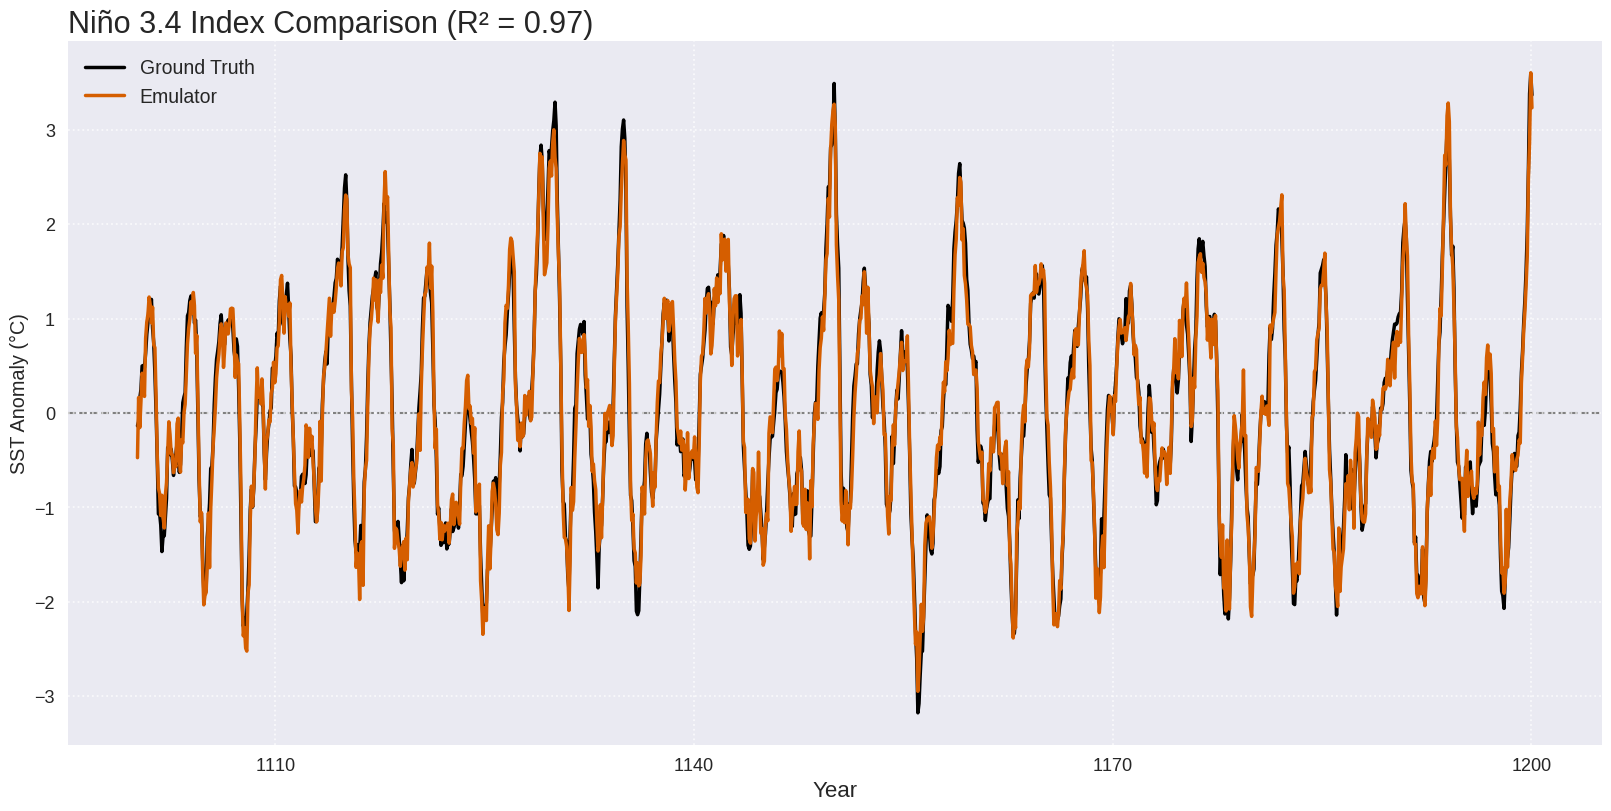

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_1pct.zarr'
BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Reconstruct_Rollout_w_Vel.zarr/'

PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'

# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO.zarr'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_New_tas.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_Add_HFDS_TAUVO_TAUUO.zarr'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_HFDS.zarr'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/Euler_Step_diffusion_54.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_Holocene_from_piControl_Long_New.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Rollout_Direct_Scaled.zarr/'

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Sea surface temperature
EMULATOR_NAME = 'Emulator'   # A descriptive name for the legend

# --- ENSO Region and Analysis Parameters ---
# Standard Niño 3.4 region definition
NINO34_REGION = {
    'lat_min': -5, 'lat_max': 5,
    'lon_min': 190, 'lon_max': 240 # Corresponds to 170W - 120W
}
# Depth slice for SST
DEPTH_SLICE = {'min': 0, 'max': 5} # Use a thin upper layer for SST
# Rolling average window in months to smooth the index
SMOOTHING_WINDOW = 1 

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTION
# ==============================================================================

def calculate_nino34_index(dataset, var_name, areacello, region, depth_slice, smoothing_window):
    """
    Calculates the Niño 3.4 index from monthly model output.
    """
    print(f"  Calculating Niño 3.4 index...")
    
    # --- 1. Spatially subset the data to the Niño 3.4 region ---
    field_regional = dataset[var_name].sel(
        y=slice(region['lat_min'], region['lat_max']),
        x=slice(region['lon_min'], region['lon_max']),
        lev=slice(depth_slice['min'], depth_slice['max'])
    )
    areacello_regional = areacello.sel(
        y=slice(region['lat_min'], region['lat_max']),
        x=slice(region['lon_min'], region['lon_max'])
    )
    
    # --- 2. Perform area-weighted average over the region ---
    # This results in a time series of the regional mean SST.
    regional_mean_ts = (field_regional * areacello_regional).sum(['x', 'y', 'lev'], skipna=True) / areacello_regional.sum(['x', 'y'])
    
    # --- 3. Calculate the anomaly ---
    # For monthly data, the anomaly is the deviation from the mean seasonal cycle.
    climatology = regional_mean_ts.groupby('time.month').mean('time', skipna=True)
    anomaly_ts = regional_mean_ts.groupby('time.month') - climatology
    
    # --- 4. Apply a rolling mean to smooth the index ---
    smoothed_anomaly = anomaly_ts.rolling(time=smoothing_window, center=True).mean()
    
    return smoothed_anomaly.compute()


# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_nino_timeseries(ts_truth, ts_emu, units):
    """
    Generates a high-quality plot comparing the Niño 3.4 index time series.
    """
    plt.style.use('seaborn-v0_8-talk')
    fig, ax = plt.subplots(figsize=(16, 8), constrained_layout=True)

    # --- Calculate R-squared value, ignoring NaNs from the rolling mean ---
    # Create a combined DataFrame to handle NaNs gracefully
    combined = xr.merge([ts_truth.rename('truth'), ts_emu.rename('emu')]).dropna('time')
    r_val, _ = pearsonr(combined['truth'].values, combined['emu'].values)
    r2_val = r_val**2
    
    # --- Plotting ---
    ts_truth.plot(ax=ax, label='Ground Truth', color='black', lw=2.5)
    ts_emu.plot(ax=ax, label=EMULATOR_NAME, color='#D55E00', lw=2.5)
    ax.axhline(0, color='gray', linestyle='--', lw=1.5, zorder=0) # Add zero line
    
    # --- Formatting ---
    ax.set_title(f"Niño 3.4 Index Comparison (R² = {r2_val:.2f})", fontsize=22, loc='left')
    ax.set_ylabel(f"SST Anomaly ({units})")
    ax.set_xlabel("Year", fontsize=16)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=14)
    
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

# The emulator data might use 'year' as the time coordinate. Rename it to 'time'.
if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

areacello = data_truth['areacello']

# --- 2. Calculate Niño 3.4 Index for both datasets ---
nino_truth = calculate_nino34_index(
    data_truth, VARIABLE_TO_PLOT, areacello, NINO34_REGION, DEPTH_SLICE, SMOOTHING_WINDOW
)
nino_emu = calculate_nino34_index(
    data_emu, VARIABLE_TO_PLOT, areacello, NINO34_REGION, DEPTH_SLICE, SMOOTHING_WINDOW
)
    
# --- 3. Generate the Plot ---
print("\nGenerating final plot...")
plot_nino_timeseries(
    ts_truth=nino_truth,
    ts_emu=nino_emu,
    units="°C"
)




Loading datasets...
  Calculating Hovmöller data...
  Calculating Hovmöller data...

Generating final plot...


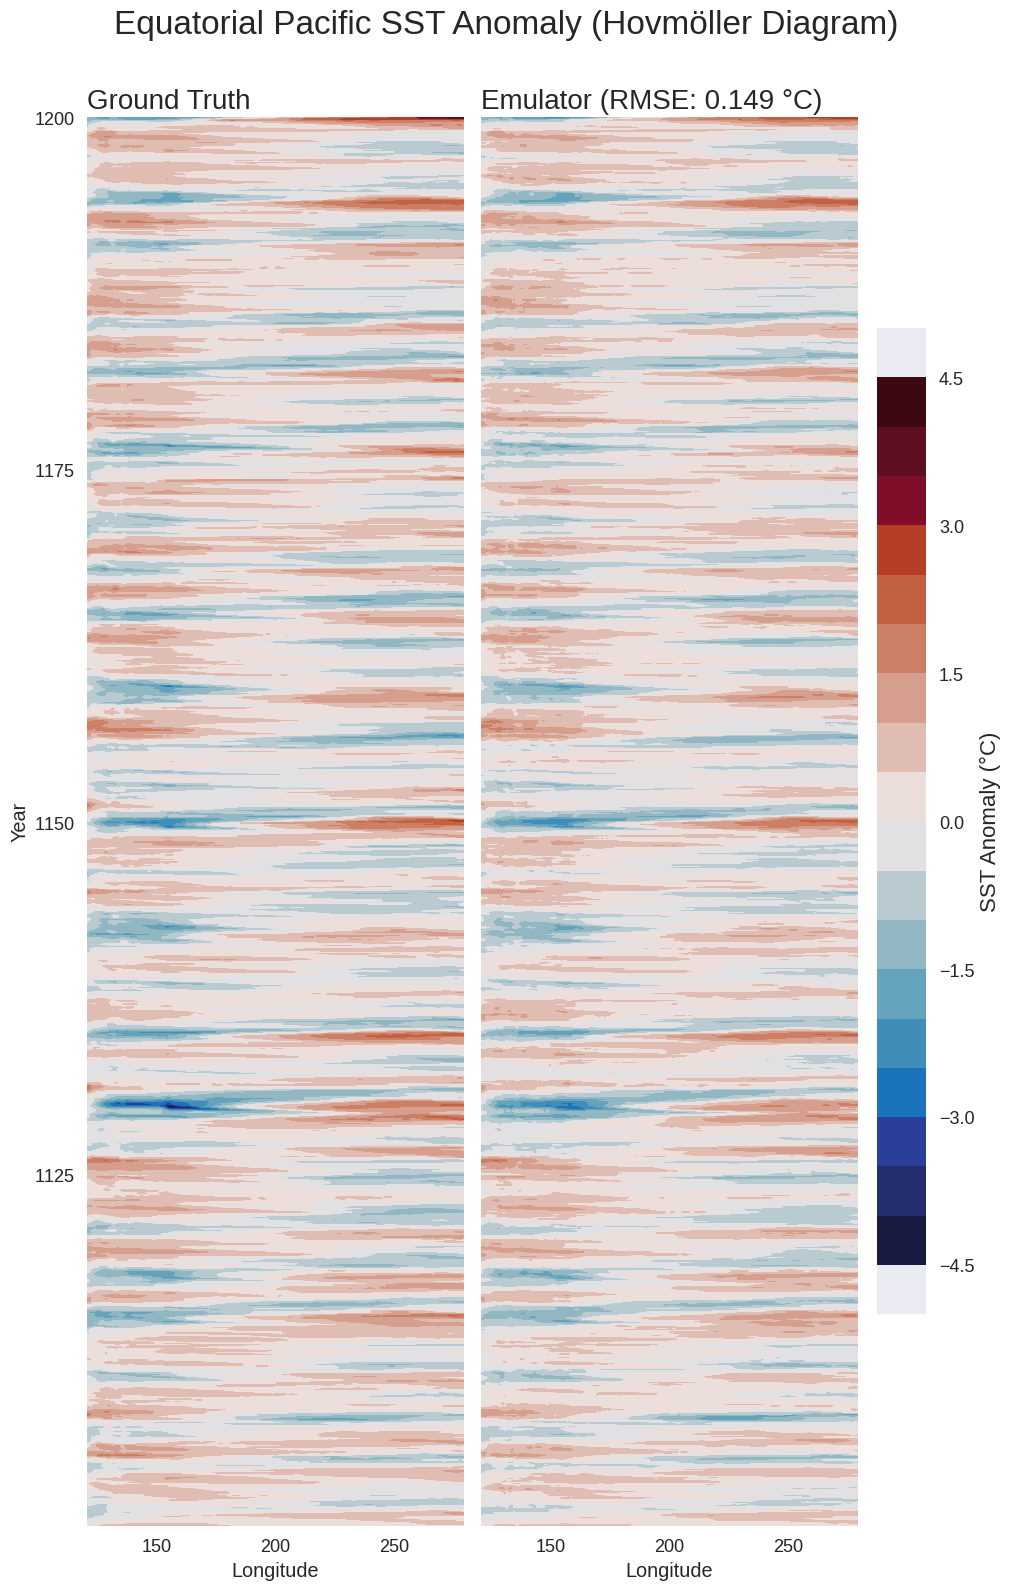

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_1pct.zarr'

BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Reconstruct_Rollout_w_Vel.zarr/'

PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'


# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_New_tas.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/CM4_Rollout_Direct_Scaled.zarr/'

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Sea surface temperature
EMULATOR_NAME = 'Emulator'   # A descriptive name for the legend

# --- ENSO Region and Analysis Parameters ---
# Hovmöller diagrams typically span the entire equatorial Pacific
HOVMOLLER_REGION = {
    'lat_min': -5, 'lat_max': 5,
    'lon_min': 120, 'lon_max': 280 # 120E - 80W
}
# Depth slice for SST
DEPTH_SLICE = {'min': 0, 'max': 250} 

# ==============================================================================
# 2. ANALYSIS HELPER FUNCTIONS
# ==============================================================================

def calculate_hovmoller_data(dataset, var_name, areacello, dz, region, depth_slice):
    """
    Calculates the data needed for a Hovmöller diagram (longitude vs. time)
    by performing a volume-weighted average over the equatorial latitude band and depth slice.
    """
    print(f"  Calculating Hovmöller data...")
    
    # --- 1. Spatially subset the data ---
    field_regional = dataset[var_name].sel(
        y=slice(region['lat_min'], region['lat_max']),
        x=slice(region['lon_min'], region['lon_max']),
        lev=slice(depth_slice['min'], depth_slice['max'])
    )
    areacello_regional = areacello.sel(
        y=slice(region['lat_min'], region['lat_max']),
        x=slice(region['lon_min'], region['lon_max'])
    )
    dz_regional = dz.sel(lev=slice(depth_slice['min'], depth_slice['max']))
    
    # --- 2. Perform volume-weighted average over latitude and depth ---
    # This results in a (time, longitude) DataArray
    weights = areacello_regional * dz_regional
    numerator = (field_regional * weights).sum(['y', 'lev'], skipna=True)
    denominator = weights.sum(['y', 'lev'])
    lat_depth_mean = numerator / denominator
    
    # --- 3. Calculate the anomaly ---
    climatology = lat_depth_mean.groupby('time.month').mean('time', skipna=True)
    anomaly_hovmoller = lat_depth_mean.groupby('time.month') - climatology
    
    return anomaly_hovmoller.compute()

def rmse(truth, pred, area, dims_to_sum=None):
    """Area-weighted RMSE."""
    # Note: For Hovmoller, area is 1D (areacello averaged over latitude)
    rmse_val = np.sqrt((area * (truth - pred)**2)).mean(dims_to_sum)
    return rmse_val

# ==============================================================================
# 3. PLOTTING FUNCTION
# ==============================================================================

def plot_hovmoller_comparison(hov_truth, hov_emu, rmse_val, units, cmap=cmocean.cm.balance):
    """
    Generates a side-by-side plot comparing Hovmöller diagrams.
    """
    plt.style.use('seaborn-v0_8-talk')
    fig, axes = plt.subplots(1, 2, figsize=(10, 15), sharey=True, constrained_layout=True)

    # Determine a shared, symmetric color scale
    max_abs_val = np.abs(hov_truth).max().item()
    vmin, vmax = -max_abs_val, max_abs_val
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    
    plot_cmap = cmap.copy()
    plot_cmap.set_bad(color='grey')

    # --- Plot Ground Truth ---
    p_truth = hov_truth.plot.contourf(
        ax=axes[0], cmap=plot_cmap, norm=norm, add_colorbar=False, levels=20
    )
    axes[0].set_title('Ground Truth', fontsize=20, loc='left')
    axes[0].set_ylabel('Year')
    axes[0].set_xlabel('Longitude')
    axes[0].grid(True, linestyle=':', alpha=0.5)

    # --- Plot Emulator ---
    hov_emu.plot.contourf(
        ax=axes[1], cmap=plot_cmap, norm=norm, add_colorbar=False, levels=20
    )
    axes[1].set_title(f'{EMULATOR_NAME} (RMSE: {rmse_val:.3f} {units})', fontsize=20, loc='left')
    axes[1].set_ylabel('')
    axes[1].set_xlabel('Longitude')
    axes[1].grid(True, linestyle=':', alpha=0.5)
    
    # --- Add a shared colorbar ---
    cbar = fig.colorbar(p_truth, ax=axes, orientation='vertical', shrink=0.7, pad=0.02)
    cbar.set_label(f"SST Anomaly ({units})", fontsize=16)
    
    fig.suptitle("Equatorial Pacific SST Anomaly (Hovmöller Diagram)", fontsize=24, y=1.05)
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION
# ==============================================================================

# --- 1. Load Datasets and Grid Info ---
print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)

areacello = data_truth['areacello']
dz = data_truth['dz']

# --- 2. Calculate Hovmöller data for both datasets ---
hovmoller_truth = calculate_hovmoller_data(
    data_truth, VARIABLE_TO_PLOT, areacello, dz, HOVMOLLER_REGION, DEPTH_SLICE
)
hovmoller_emu = calculate_hovmoller_data(
    data_emu, VARIABLE_TO_PLOT, areacello, dz, HOVMOLLER_REGION, DEPTH_SLICE
)
    
# --- 3. Calculate RMSE ---
# For weighting, we need the area summed over the latitude band
area_1d = xr.ones_like(areacello.sel(
    y=slice(HOVMOLLER_REGION['lat_min'], HOVMOLLER_REGION['lat_max']),
    x=slice(HOVMOLLER_REGION['lon_min'], HOVMOLLER_REGION['lon_max'])
).sum('y'))

rmse_val = rmse(hovmoller_truth, hovmoller_emu, area_1d, dims_to_sum=['time', 'x']).values

# --- 4. Generate the Plot ---
print("\nGenerating final plot...")
plot_hovmoller_comparison(
    hov_truth=hovmoller_truth,
    hov_emu=hovmoller_emu,
    rmse_val=rmse_val,
    units="°C"
)



In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# --- Define paths to datasets ---
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/CM4_CMIP_New_Detrended.zarr'
# PATH_TRUTH_DATA = f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr'

# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_New_tas.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_CM4_Forcings_HFDS.zarr/'
# PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel.zarr/'
PATH_EMU_DATA = '/pscratch/sd/a/asubel/Chapter_2/Preds/BVP_piControl_w_Vel_Multistep.zarr/'

# --- Define analysis parameters ---
VARIABLE_TO_PLOT = 'thetao'  # Sea surface temperature
EMULATOR_NAME = 'Emulator'   # A descriptive name for the legend

# --- ENSO Region and Analysis Parameters ---
# Hovmöller diagrams typically span the entire equatorial Pacific
HOVMOLLER_REGION = {
    'lat_min': -5, 'lat_max': 5,
    'lon_min': 120, 'lon_max': 280 # 120E - 80W
}
# Depth slice for SST
DEPTH_SLICE = {'min': 0, 'max': 250} 


def calculate_amoc(dataset,TIME_WINDOW = slice(0,None)):
    """Calculates the time-mean Atlantic Meridional Overturning Circulation (AMOC)."""
    vo_mean = dataset['sea_water_y_velocity'].isel(time=TIME_WINDOW).mean('time').compute()
    v_vel = vo_mean * atlantic_mask
    v_int_x = (v_vel * dx * dataset.dz).sum('lon', skipna=True)
    moc = (v_int_x).cumsum('lev') - (v_int_x).sum('lev')
    return moc / 1e6 # Return in Sverdrups
    
def calculate_amoc_timeseries(dataset: xr.Dataset,
                              lat_bound: slice = slice(27.5,32.5),
                              reduce_method: str = 'max',
                              window: int = 60,):
    """Calculates the time-mean Atlantic Meridional Overturning Circulation (AMOC)."""
    vo_mean = dataset['sea_water_y_velocity'].sel(lat=lat_bound)
    v_vel = vo_mean * atlantic_mask
    v_int_x = (v_vel * dx * dataset.dz).sum('lon', skipna=True)
    moc = (v_int_x).cumsum('lev') - (v_int_x).sum('lev')
    if reduce_method == 'max':
        moc = moc.max(['lev','lat'])
    else:
        moc = moc.mean(['lev','lat'])
    return moc.rolling(time=window, center=True).mean().dropna('time').compute() / 1e6 # Return in Sverdrups    


print("Loading datasets...")
data_truth = xr.open_zarr(PATH_TRUTH_DATA, consolidated=True)
data_emu = xr.open_zarr(PATH_EMU_DATA, consolidated=True)

if 'year' in data_emu.coords:
    data_emu = data_emu.rename({'year': 'time'})

time_slice = slice(data_emu['time'][0].values, data_emu['time'][-1].values)
data_truth = data_truth.sel(time=time_slice)


moc_mean = calculate_amoc(dataset_stacked)
moc_mean = moc_mean.where(moc_mean!=0.0,np.nan)

moc_truth_mean = calculate_amoc(dataset_stacked_truth)
moc_truth_mean = moc_truth_mean.where(moc_truth_mean!=0.0,np.nan)

error_mean = moc_mean - moc_truth_mean


moc_timeseries = calculate_amoc_timeseries(dataset_stacked)
moc_timeseries_anoms = moc_timeseries.groupby('time.month') - moc_timeseries.groupby('time.month').mean('time')
moc_truth_timeseries = calculate_amoc_timeseries(dataset_stacked_truth)
moc_truth_timeseries_anoms = moc_truth_timeseries.groupby('time.month') - moc_truth_timeseries.groupby('time.month').mean('time')
moc_timeseries_uncoupled = calculate_amoc_timeseries(dataset_stacked_uncoupled)
moc_timeseries_anoms_uncoupled = moc_timeseries_uncoupled.groupby('time.month') - moc_timeseries_uncoupled.groupby('time.month').mean('time')

error_timeseries = moc_timeseries - moc_truth_timeseries